# Objectives
The objective of this lab is to practice essential data analysis techniques using Pandas. It focuses on performing fundamental operations with Pandas, including creating, manipulating, and analyzing data. Through hands-on tasks, you will learn how to:

1. **Create DataFrames**: Understand how to construct DataFrames from dictionaries and other sources.
2. **Read and Write Data**: Work with various file types like CSV and Excel files to load and save datasets.
3. **Perform Basic Statistical Analysis**: Calculate descriptive statistics such as mean, standard deviation, and transformations of data columns.
4. **Data Cleaning and Transformation**: Handle missing values, apply mathematical operations, and reshape data.
5. **Group and Aggregate Data**: Use grouping and aggregation techniques to summarize data effectively.

The overall goal is to build confidence in using Pandas for real-world data analysis tasks and lay a foundation for more advanced analytics workflows.

## **Example 1: Importing Libraries**

In [146]:
# Import necessary libraries for the lab
import pandas as pd  # For data manipulation and analysis
import numpy as np  # For numerical operations
import matplotlib.pyplot as plt  # For plotting

# Enable inline plotting in Jupyter Notebooks
%matplotlib inline  

# Set a consistent style for plots
plt.style.use('seaborn-v0_8-whitegrid')  # Use a clean grid style
plt.rc('font', family='times')  # Set font to 'Times'
plt.rc('xtick', labelsize=10)  # Set size of x-axis labels
plt.rc('ytick', labelsize=10)  # Set size of y-axis labels
plt.rc('font', size=12)  # Set overall font size

## **Example 2: Creating a DataFrame from a Dictionary**

In [147]:
# Create a DataFrame using a dictionary of lists
data = {
    'year': [2010, 2011, 2012, 2010, 2011, 2012, 2010, 2011, 2012],
    'team': ['FCBarcelona', 'FCBarcelona', 'FCBarcelona',
             'RMadrid', 'RMadrid', 'RMadrid',
             'ValenciaCF', 'ValenciaCF', 'ValenciaCF'],
    'wins': [30, 28, 32, 29, 32, 26, 21, 17, 19],
    'draws': [6, 7, 4, 5, 4, 7, 8, 10, 8],
    'losses': [2, 3, 2, 4, 2, 5, 9, 11, 11]
}

# Construct the DataFrame and specify column order
football = pd.DataFrame(data, columns=['year', 'team', 'wins', 'draws', 'losses'])

# Display the DataFrame
football

,year,team,wins,draws,losses
0,2010,FCBarcelona,30,6,2
1,2011,FCBarcelona,28,7,3
2,2012,FCBarcelona,32,4,2
3,2010,RMadrid,29,5,4
4,2011,RMadrid,32,4,2
5,2012,RMadrid,26,7,5
6,2010,ValenciaCF,21,8,9
7,2011,ValenciaCF,17,10,11
8,2012,ValenciaCF,19,8,11


## **Example 3: Reading Data from a CSV File**

In [148]:
# Read a CSV file into a DataFrame, specifying how to handle missing values
edu = pd.read_csv('education_analysis.csv', 
                  na_values=':',  # Treat ':' as NaN
                  usecols=['TIME', 'GEO', 'Value'])  # Select specific columns

# Display the resulting DataFrame
edu

,TIME,GEO,Value
0,2000,European Union (28 countries),NaN
1,2001,European Union (28 countries),NaN
2,2002,European Union (28 countries),5.00
3,2003,European Union (28 countries),5.03
4,2004,European Union (28 countries),4.95
...,...,...,...
379,2007,Finland,5.90
380,2008,Finland,6.10
381,2009,Finland,6.81
382,2010,Finland,6.85


## **Example 4: Viewing Data**

In [149]:
# Display the first 5 rows of the DataFrame
edu.head()

,TIME,GEO,Value
0,2000,European Union (28 countries),NaN
1,2001,European Union (28 countries),NaN
2,2002,European Union (28 countries),5.00
3,2003,European Union (28 countries),5.03
4,2004,European Union (28 countries),4.95


In [150]:
# Display the last 5 rows of the DataFrame
edu.tail()

,TIME,GEO,Value
379,2007,Finland,5.90
380,2008,Finland,6.10
381,2009,Finland,6.81
382,2010,Finland,6.85
383,2011,Finland,6.76


In [151]:
# Display column names
edu.columns

Index(['TIME', 'GEO', 'Value'], dtype='object')

In [152]:
# Display index information
edu.index

RangeIndex(start=0, stop=384, step=1)

In [153]:
# Display DataFrame values as a NumPy array
edu.values

array([[2000, 'European Union (28 countries)', nan],
       [2001, 'European Union (28 countries)', nan],
       [2002, 'European Union (28 countries)', 5.0],
       ...,
       [2009, 'Finland', 6.81],
       [2010, 'Finland', 6.85],
       [2011, 'Finland', 6.76]], dtype=object)

In [154]:
# Display summary statistics for numeric columns
edu.describe()

,TIME,Value
count,384.000000,361.000000
mean,2005.500000,5.203989
std,3.456556,1.021694
min,2000.000000,2.880000
25%,2002.750000,4.620000
50%,2005.500000,5.060000
75%,2008.250000,5.660000
max,2011.000000,8.810000


## **Example 5: Selecting Data**

In [155]:
# Select a specific column as a Series
edu['Value']

0       NaN
1       NaN
2      5.00
3      5.03
4      4.95
       ... 
379    5.90
380    6.10
381    6.81
382    6.85
383    6.76
Name: Value, Length: 384, dtype: float64

In [156]:
# Select rows from the 10th to the 13th position (inclusive of the start, exclusive of the end)
edu[10:14]

,TIME,GEO,Value
10,2010,European Union (28 countries),5.41
11,2011,European Union (28 countries),5.25
12,2000,European Union (27 countries),4.91
13,2001,European Union (27 countries),4.99


In [157]:
# Select rows and columns using labels
edu.loc[90:94, :]

,TIME,GEO,Value
90,2006,Belgium,5.98
91,2007,Belgium,6.00
92,2008,Belgium,6.43
93,2009,Belgium,6.57
94,2010,Belgium,6.58


## **Example 6: Filtering Data**

In [158]:
# Filter rows where the 'Value' column is greater than 6.5
edu[edu['Value'] > 6.5].tail()

,TIME,GEO,Value
286,2010,Malta,6.74
287,2011,Malta,7.96
381,2009,Finland,6.81
382,2010,Finland,6.85
383,2011,Finland,6.76


In [159]:
# Filter rows with missing 'Value' data
edu[edu['Value'].isnull()].head()

,TIME,GEO,Value
0,2000,European Union (28 countries),NaN
1,2001,European Union (28 countries),NaN
36,2000,Euro area (18 countries),NaN
37,2001,Euro area (18 countries),NaN
48,2000,Euro area (17 countries),NaN


## **Example 7: Aggregation Functions**

In [160]:
# Aggregation function example: Maximum value along columns
edu.max(axis=0)

TIME      2011
GEO      Spain
Value     8.81
dtype: object

## **Example 8: Comparing Pandas and Python Functions**

In [161]:
# Pandas max function
print('Pandas max function:', edu['Value'].max())

# Python max function
print('Python max function:', max(edu['Value']))

Pandas max function: 8.81
Python max function: nan


## **Example 9: Element-wise Operations**

In [162]:
# Divide all values in 'Value' column by 100
s = edu['Value'] / 100
s.head()  # Display the first 5 rows of the series

0       NaN
1       NaN
2    0.0500
3    0.0503
4    0.0495
Name: Value, dtype: float64

## **Example 10: Using apply with a Function**

In [163]:
# Apply square root to 'Value' column
s = edu['Value'].apply(np.sqrt)
s.head()  # Display the first 5 rows

0         NaN
1         NaN
2    2.236068
3    2.242766
4    2.224860
Name: Value, dtype: float64

## **Example 11: Using Lambda Functions**

In [164]:
# Square each value in 'Value' column using a lambda function
s = edu['Value'].apply(lambda d: d**2)
s.head()  # Display the first 5 rows


0        NaN
1        NaN
2    25.0000
3    25.3009
4    24.5025
Name: Value, dtype: float64

## **Example 12: Adding and Dropping Columns**

In [165]:
# Normalize 'Value' column and add it as a new column
edu['ValueNorm'] = edu['Value'] / edu['Value'].max()
edu.tail()  # Display the last 5 rows

,TIME,GEO,Value,ValueNorm
379,2007,Finland,5.90,0.669694
380,2008,Finland,6.10,0.692395
381,2009,Finland,6.81,0.772985
382,2010,Finland,6.85,0.777526
383,2011,Finland,6.76,0.767310


In [166]:
# Remove 'ValueNorm' column
edu.drop('ValueNorm', axis=1, inplace=True)
edu.head()  # Display the first 5 rows

,TIME,GEO,Value
0,2000,European Union (28 countries),NaN
1,2001,European Union (28 countries),NaN
2,2002,European Union (28 countries),5.00
3,2003,European Union (28 countries),5.03
4,2004,European Union (28 countries),4.95


In [167]:
# Concatenates two DataFrames along a specified axis.
new_row = pd.DataFrame({'TIME': [2000], 'Value': [5.00], 'GEO': ['a']})
edu = pd.concat([edu, new_row], ignore_index=True)
edu.tail()

,TIME,GEO,Value
380,2008,Finland,6.10
381,2009,Finland,6.81
382,2010,Finland,6.85
383,2011,Finland,6.76
384,2000,a,5.00


In [168]:
edu.drop(max(edu.index), axis=0, inplace=True)
edu.tail()

,TIME,GEO,Value
379,2007,Finland,5.90
380,2008,Finland,6.10
381,2009,Finland,6.81
382,2010,Finland,6.85
383,2011,Finland,6.76


## **Example 13: Removing Rows**

In [169]:
# Drop rows with NaN values in 'Value' column
eduDrop = edu.dropna(how='any', subset=['Value'], axis=0)
eduDrop.head()  # Display the first 5 rows

,TIME,GEO,Value
2,2002,European Union (28 countries),5.00
3,2003,European Union (28 countries),5.03
4,2004,European Union (28 countries),4.95
5,2005,European Union (28 countries),4.92
6,2006,European Union (28 countries),4.91


## **Example 14: Filling Missing Values**

In [170]:
# Replace NaN values in 'Value' column with 0
eduFilled = edu.fillna(value={'Value': 0})
eduFilled.head()  # Display the first 5 rows

,TIME,GEO,Value
0,2000,European Union (28 countries),0.00
1,2001,European Union (28 countries),0.00
2,2002,European Union (28 countries),5.00
3,2003,European Union (28 countries),5.03
4,2004,European Union (28 countries),4.95


## **Example 15: Sorting Data**

In [171]:
# Sorting by 'Value' column in descending order
edu.sort_values(by='Value', ascending=False, inplace=True)
edu.head()

,TIME,GEO,Value
130,2010,Denmark,8.81
131,2011,Denmark,8.75
129,2009,Denmark,8.74
121,2001,Denmark,8.44
122,2002,Denmark,8.44


In [172]:
# Sorting by index in ascending order
edu.sort_index(axis=0, ascending=True, inplace=True)
edu.head()

,TIME,GEO,Value
0,2000,European Union (28 countries),NaN
1,2001,European Union (28 countries),NaN
2,2002,European Union (28 countries),5.00
3,2003,European Union (28 countries),5.03
4,2004,European Union (28 countries),4.95


## **Example 16: Grouping and Aggregation**

In [173]:
# Group data by 'GEO' column and calculate the mean for each group
group = edu[['GEO', 'Value']].groupby('GEO').mean()
group.head()  # Display the first 5 rows

,Value
GEO,
Austria,5.618333
Belgium,6.189091
Bulgaria,4.093333
Cyprus,7.023333
Czech Republic,4.168333


## **Example 17: Using Pivot Tables**

In [174]:
# Pivot data to display values per year for each country
filtered_data = edu[edu['TIME'] > 2005]
pivedu = pd.pivot_table(filtered_data, values='Value', index=['GEO'], columns=['TIME'])
pivedu.head()  # Display the pivoted DataFrame

TIME,2006,2007,2008,2009,2010,2011
GEO,,,,,,
Austria,5.40,5.33,5.47,5.98,5.91,5.80
Belgium,5.98,6.00,6.43,6.57,6.58,6.55
Bulgaria,4.04,3.88,4.44,4.58,4.10,3.82
Cyprus,7.02,6.95,7.45,7.98,7.92,7.87
Czech Republic,4.42,4.05,3.92,4.36,4.25,4.51


In [175]:
# Pivot data to use the new index to select specific rows by label
pivedu.loc[['Spain', 'Portugal'], [2006, 2011]]

TIME,2006,2011
GEO,,
Spain,4.26,4.82
Portugal,5.07,5.27


## **Example 18: Ranking Data**

In [176]:
# Drop unnecessary rows and clean up data
pivedu = pivedu.drop(['Euro area (13 countries)',
                      'Euro area (15 countries)',
                      'Euro area (17 countries)',
                      'Euro area (18 countries)',
                      'European Union (25 countries)',
                      'European Union (27 countries)',
                      'European Union (28 countries)'], axis=0)

# Rename country for consistency
pivedu = pivedu.rename({'Germany (until 1990 former territory of the FRG)': 'Germany'})

# Drop rows with NaN values
pivedu = pivedu.dropna()

# Rank countries based on values, highest to lowest
pivedu.rank(ascending=False, method='first').head()

TIME,2006,2007,2008,2009,2010,2011
GEO,,,,,,
Austria,10.0,7.0,11.0,7.0,8.0,8.0
Belgium,5.0,4.0,3.0,4.0,5.0,5.0
Bulgaria,21.0,21.0,20.0,20.0,22.0,22.0
Cyprus,2.0,2.0,2.0,2.0,2.0,3.0
Czech Republic,19.0,20.0,21.0,21.0,20.0,19.0


## **Example 19: Global Ranking Over All Years**

In [177]:
# Calculate total sum for ranking
totalSum = pivedu.sum(axis=1)

# Rank countries based on accumulated values over the last 6 years
totalSum.rank(ascending=False, method='dense').sort_values().head()

GEO
Denmark    1.0
Cyprus     2.0
Finland    3.0
Malta      4.0
Belgium    5.0
dtype: float64

## **Example 20: Plotting Data**

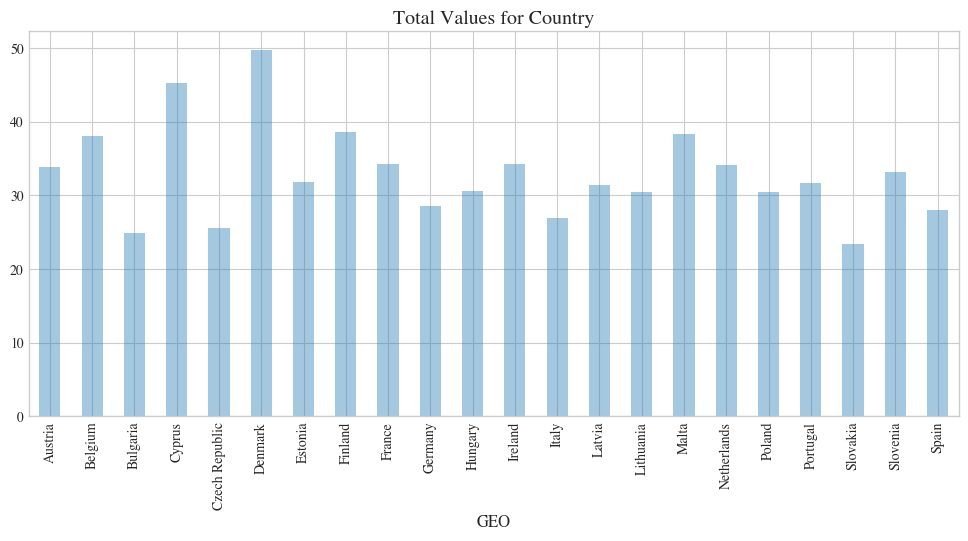

In [178]:
# Initialize plot size
fig = plt.figure(figsize=(12, 5))

# Plot total values for countries as a bar graph
totalSum.plot(kind='bar', style='b', alpha=0.4,
              title='Total Values for Country')

# Save the figure
plt.savefig('TotalValue_Country.png', dpi=300, bbox_inches='tight')


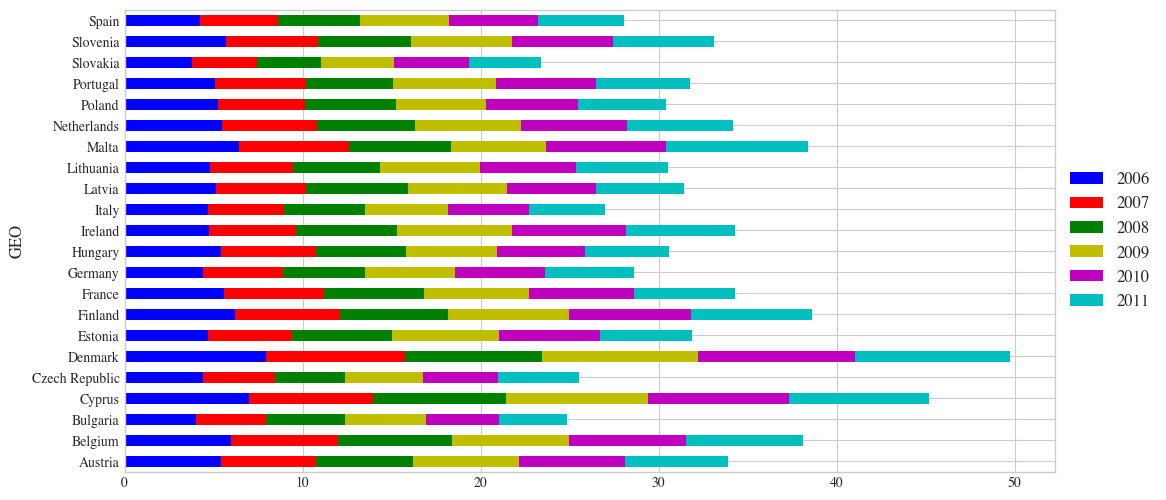

In [179]:
# Define custom colors
my_colors = ['b', 'r', 'g', 'y', 'm', 'c']

# Plot the data
ax = pivedu.plot(kind='barh', stacked=True, color=my_colors, figsize=(12, 6))

# Add a legend outside the plot
ax.legend(loc='center left', bbox_to_anchor=(1, 0.5))

# Save the plot
plt.savefig('Value_Time_Country.png', dpi=300, bbox_inches='tight')

## **Question 1: Recreate the DataFrame Using `from_dict`**

**Task**: Recreate the DataFrame above using the `from_dict` method.

- The from_dict method creates a DataFrame from a dictionary. Each key becomes a column, and the corresponding values become the data.

In [180]:
import pandas as pd

# Recreate the DataFrame using from_dict
data = {
    'year': [2010, 2011, 2012, 2010, 2011, 2012, 2010, 2011, 2012],
    'team': ['FCBarcelona', 'FCBarcelona', 'FCBarcelona', 
             'RMadrid', 'RMadrid', 'RMadrid', 
             'ValenciaCF', 'ValenciaCF', 'ValenciaCF'],
    'wins': [30, 28, 32, 29, 32, 26, 21, 17, 19],
    'draws': [6, 7, 4, 5, 4, 7, 8, 10, 8],
    'losses': [2, 3, 2, 4, 2, 5, 9, 11, 11]
}

football = pd.DataFrame.from_dict(data)
football

,year,team,wins,draws,losses
0,2010,FCBarcelona,30,6,2
1,2011,FCBarcelona,28,7,3
2,2012,FCBarcelona,32,4,2
3,2010,RMadrid,29,5,4
4,2011,RMadrid,32,4,2
5,2012,RMadrid,26,7,5
6,2010,ValenciaCF,21,8,9
7,2011,ValenciaCF,17,10,11
8,2012,ValenciaCF,19,8,11


## **Question 2: Read a Non-CSV File**

**Task**: Read a non-CSV file (e.g., Excel) into a DataFrame.

- The `pd.read_excel()` function is used to read Excel files.
- Use the `head()` method to display the first few rows.

In [181]:
# Example of reading an Excel file
excel_file_path = 'heads_of_state.xlsx'
q_2 = pd.read_excel(excel_file_path)
q_2.head()


,Unnamed: 0,Name,Took office,Left office,Military/Civilian,Age Took Office,Died in Office?,Days in Office
0,1,Dr. Nanmdi Azikiwe,1960-11-16,1966-01-16,Civilian,56,No,1887.0
1,2,Major General Johnson Aguiyi-Ironsi,1966-01-16,1966-07-29,Military,42,Yes,194.0
2,3,General Yakubu Gowon,1966-08-01,1975-07-29,Military,32,No,3284.0
3,4,General Murtala Mohammed,1975-07-29,1976-02-13,Military,37,Yes,199.0
4,5,General Olusegun Obasanjo,1976-02-13,1979-10-01,Military,39,No,1326.0


### **Question 3: Calculate the Mean and Standard Deviation of the `Value` Column**

**Task**: Compute the average and standard deviation of the `Value` column in the `edu` DataFrame.


- The `mean()` and `std()` methods compute the mean and standard deviation, excluding NaN values by default.

In [182]:
edu = pd.read_csv('education_analysis.csv', na_values=':', usecols=['TIME', 'GEO', 'Value'])

# Calculate mean and standard deviation
mean_value = edu['Value'].mean()
std_value = edu['Value'].std()

print(f"Mean: {mean_value}")
print(f"Standard Deviation: {std_value}")


Mean: 5.20398891966759
Standard Deviation: 1.0216944748195935


### **Question 4: Calculate the Ceil of the Scalar Square Root of `Value`**

**Task**: Compute the square root of the `Value` column, take its ceil, and display the result.

- Use `apply()` to apply a function to each value in the column.
- Use `np.sqrt()` to calculate the square root and `np.ceil()` to round up.


In [183]:
import numpy as np

# Compute the square root and ceil
edu['sqrt_ceil'] = edu['Value'].apply(np.sqrt).apply(np.ceil)
edu[['Value', 'sqrt_ceil']].head()

,Value,sqrt_ceil
0,NaN,NaN
1,NaN,NaN
2,5.00,3.0
3,5.03,3.0
4,4.95,3.0


### **Question 5: Calculate the Mean of `Value` for Each Country Per Year**

**Task**: Group the data by `GEO` and `TIME` to calculate the mean `Value`.

- The `groupby()` method groups the data by `GEO` (country) and `TIME` (year).
- The `mean()` function calculates the mean for each group.

In [184]:
# Group by GEO and TIME, then calculate mean
mean_per_year = edu.groupby(['GEO', 'TIME'])['Value'].mean()
print(mean_per_year)

GEO      TIME
Austria  2000    5.66
         2001    5.74
         2002    5.68
         2003    5.53
         2004    5.48
                 ... 
Spain    2007    4.34
         2008    4.62
         2009    5.02
         2010    4.98
         2011    4.82
Name: Value, Length: 384, dtype: float64


# Summary

In this lab, I explored the fundamental functionalities of Pandas for data analysis and manipulation. Starting with the creation of DataFrames using the `from_dict` method, I learned how to structure data in tabular format. I also practiced reading data from external files like CSV and Excel, with a focus on handling missing values by specifying custom markers (`na_values`).

- The solutions illustrate key Pandas functionalities like creating DataFrames, reading data, filtering, grouping, and aggregation.
- Each section in the notebook includes comments and explanations to demonstrate the thought process.